<a href="https://colab.research.google.com/github/nisha948881-max/Project/blob/main/HR_EMPLOYEE_ATTRITION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving employee_attrition.csv to employee_attrition.csv
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.6 MB/s eta 0:00:00
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3   

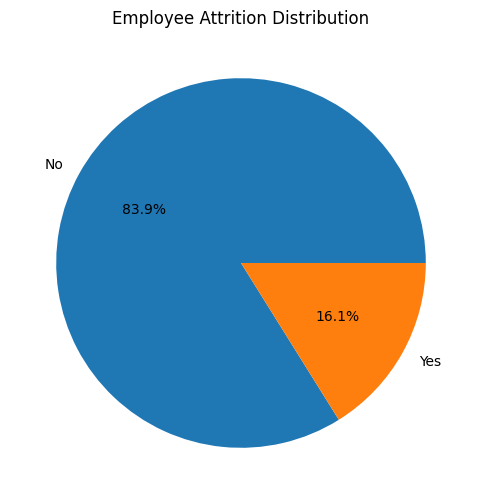

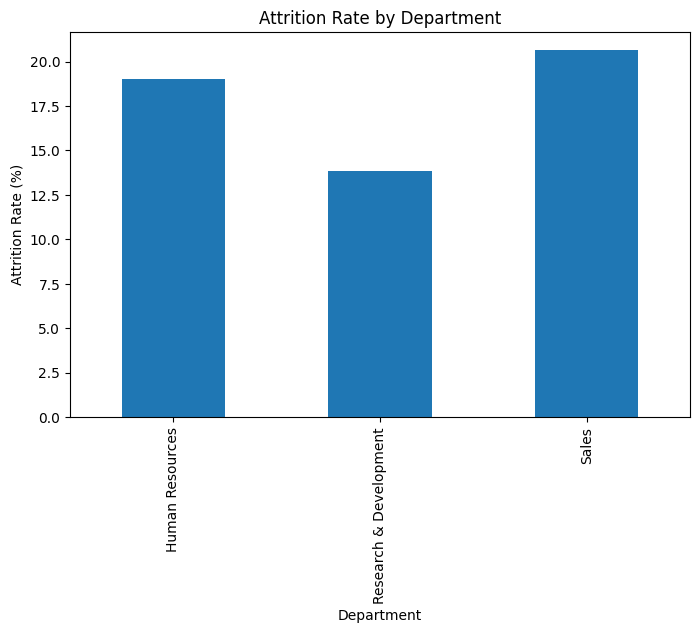

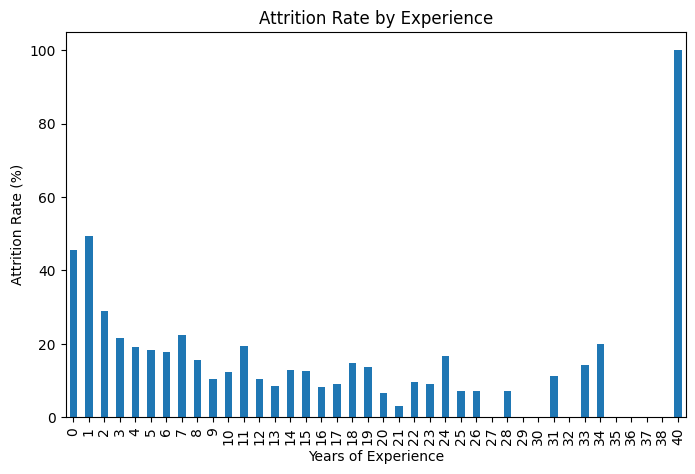

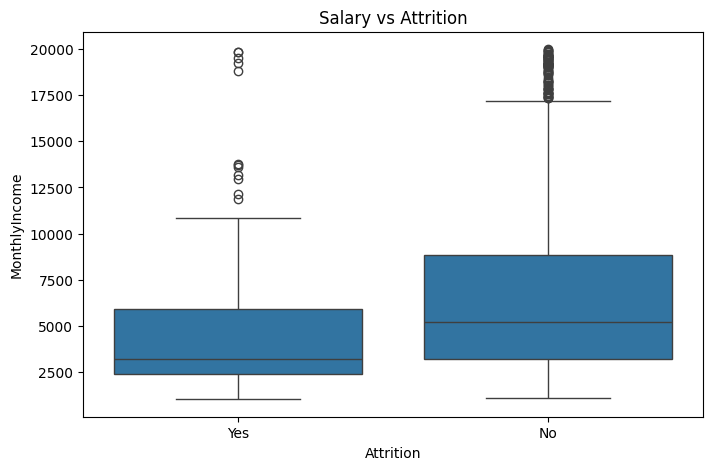


Key Insights:
1. Department with highest attrition:
Sales

2. Experience group with highest attrition:
40

3. Average Salary by Attrition:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Install Streamlit if not already installed
!pip install streamlit
import streamlit as st

# If Seaborn is not installed, then run:
!pip install seaborn

df = pd.read_csv("employee_attrition.csv")        # you have to give the file path
print(df.head())

# HR Employee Attrition Analysis

# Removed redundant imports:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# ---------------------------
# 1. Load Dataset
# ---------------------------
df = pd.read_csv("employee_attrition.csv")

print("First 5 Records:")
print(df.head())

# ---------------------------
# 2. Data Cleaning
# ---------------------------

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Fill missing values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median()) # Corrected column name
df['TotalWorkingYears'] = df['TotalWorkingYears'].fillna(df['TotalWorkingYears'].median()) # Corrected column name

print("\nDataset Info:")
print(df.info())

# ---------------------------
# 3. Overall Attrition Rate
# ---------------------------

attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100)

print("\nAttrition Rate:")
print(attrition_rate)

# ---------------------------
# 4. Attrition by Department
# ---------------------------

dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print("\nAttrition by Department:")
print(dept_attrition)

# ---------------------------
# 5. Attrition by Salary
# ---------------------------

salary_attrition = df.groupby('MonthlyIncome')['Attrition'].apply( # Corrected column name
    lambda x: (x == 'Yes').mean() * 100
)

print("\nAttrition by Salary:")
print(salary_attrition)

# ---------------------------
# 6. Attrition by Experience
# ---------------------------

exp_attrition = df.groupby('TotalWorkingYears')['Attrition'].apply( # Corrected column name
    lambda x: (x == 'Yes').mean() * 100
)

print("\nAttrition by Experience:")
print(exp_attrition)

# ---------------------------
# 7. Visualization
# ---------------------------

# Pie Chart - Overall Attrition
plt.figure(figsize=(6,6))
df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Employee Attrition Distribution")
plt.ylabel("")
plt.show()

# Bar Graph - Department Attrition
plt.figure(figsize=(8,5))
dept_attrition.plot(kind='bar')
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

# Bar Graph - Experience Attrition
plt.figure(figsize=(8,5))
exp_attrition.plot(kind='bar')
plt.title("Attrition Rate by Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Attrition Rate (%)")
plt.show()

# Salary Distribution by Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df) # Corrected column name
plt.title("Salary vs Attrition")
plt.show()

# ---------------------------
# 8. Key Factors Analysis
# ---------------------------

print("\nKey Insights:")
print("1. Department with highest attrition:")
print(dept_attrition.idxmax())

print("\n2. Experience group with highest attrition:")
print(exp_attrition.idxmax())

print("\n3. Average Salary by Attrition:")
print(df.groupby('Attrition')['MonthlyIncome'].mean()) # Corrected column name


### Running the Streamlit App

To view your Streamlit application, you need to run it as a separate server and expose it through a public URL. We will use `localtunnel` for this purpose.

**Important:** After executing the next cell, click on the generated `External URL` to open your Streamlit dashboard in a new tab.

In [ ]:
# Install localtunnel to expose the Streamlit app
!npm install localtunnel

# Save the Streamlit app code to a Python file
# This is necessary because Streamlit runs from a file
streamlit_code = '''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

# ---------------------------
# 1. Load Dataset (assuming employee_attrition.csv is uploaded)
# ---------------------------
df = pd.read_csv("employee_attrition.csv")

# ---------------------------
# 2. Data Cleaning (re-apply from previous steps for the app)
# ---------------------------
df = df.drop_duplicates()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['TotalWorkingYears'] = df['TotalWorkingYears'].fillna(df['TotalWorkingYears'].median())

# ---------------------------
# 3. Overall Attrition Rate
# ---------------------------
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100)

# ---------------------------
# 4. Attrition by Department
# ---------------------------
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

# ---------------------------
# 5. Attrition by Salary
# ---------------------------
salary_attrition = df.groupby('MonthlyIncome')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

# ---------------------------
# 6. Attrition by Experience
# ---------------------------
exp_attrition = df.groupby('TotalWorkingYears')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)


# Streamlit Dashboard Layout
st.set_page_config(layout="wide")
st.title("HR Employee Attrition Dashboard")

st.markdown("--- ")

# Overall Attrition Rate
st.subheader("Overall Employee Attrition Rate")
attrition_data = pd.DataFrame({
    'Attrition': attrition_rate.index,
    'Percentage': attrition_rate.values
})
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.pie(attrition_data['Percentage'], labels=attrition_data['Attrition'], autopct='%1.1f%%', startangle=90)
ax1.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
st.pyplot(fig1)

st.markdown("--- ")

# Attrition by Department
st.subheader("Attrition Rate by Department")
fig2, ax2 = plt.subplots(figsize=(8, 5))
dept_attrition.plot(kind='bar', ax=ax2)
ax2.set_title("Attrition Rate by Department")
ax2.set_xlabel("Department")
ax2.set_ylabel("Attrition Rate (%)")
st.pyplot(fig2)

st.markdown("--- ")

# Attrition by Experience
st.subheader("Attrition Rate by Experience (Years)")
fig3, ax3 = plt.subplots(figsize=(10, 6))
exp_attrition.plot(kind='bar', ax=ax3)
ax3.set_title("Attrition Rate by Experience")
ax3.set_xlabel("Years of Experience")
ax3.set_ylabel("Attrition Rate (%)")
st.pyplot(fig3)

st.markdown("--- ")

# Salary Distribution by Attrition
st.subheader("Salary Distribution by Attrition")
fig4, ax4 = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=ax4)
ax4.set_title("Salary vs Attrition")
st.pyplot(fig4)

st.markdown("--- ")

# Attrition Rate by Salary (Table)
st.subheader("Attrition Rate by Monthly Income")
st.dataframe(
    salary_attrition.reset_index().rename(
        columns={
            'MonthlyIncome': 'Monthly Income',
            'Attrition': 'Attrition Rate (%)'
        }
    )
)

# Key Factors Analysis
st.subheader("Key Insights")
st.write(f"1. Department with highest attrition: **{dept_attrition.idxmax()}**")
st.write(f"2. Experience group with highest attrition: **{exp_attrition.idxmax()} years**")
st.write(f"3. Average Salary for Attrited Employees: **{df.groupby('Attrition')['MonthlyIncome'].mean()['Yes']:.2f}**")
st.write(f"4. Average Salary for Non-Attrited Employees: **{df.groupby('Attrition')['MonthlyIncome'].mean()['No']:.2f}**")

'''

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

# Run the Streamlit app and expose it via localtunnel
!streamlit run streamlit_app.py &>/dev/null&  \n  npx localtunnel --port 8501